<a href="https://colab.research.google.com/github/shawnadamz/my-data/blob/main/Bilal%20Abubakar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

__________________________________________________
Step 4: DATA ACQUISITION
__________________________________________________
Connecting to UCI ML Repository...

Dataset successfully retrieved.

Features:
   age gender polyuria polydipsia sudden_weight_loss weakness polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  genital_thrush visual_blurring itching irritability delayed_healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes     

/tmp/ipykernel_903/347386040.py:210: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  symptom_data = (df[available_columns].replace(binary_values))
/tmp/ipykernel_903/347386040.py:304: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace(target_mapping)



Training Logistic Regression...
Logistic Regression training completed.

Training Random Forest...
Random Forest training completed.

MODEL PERFORMANCE
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.942308   0.983333  0.921875  0.951613  0.990625
1        Random Forest  0.990385   0.984615  1.000000  0.992248  0.997852


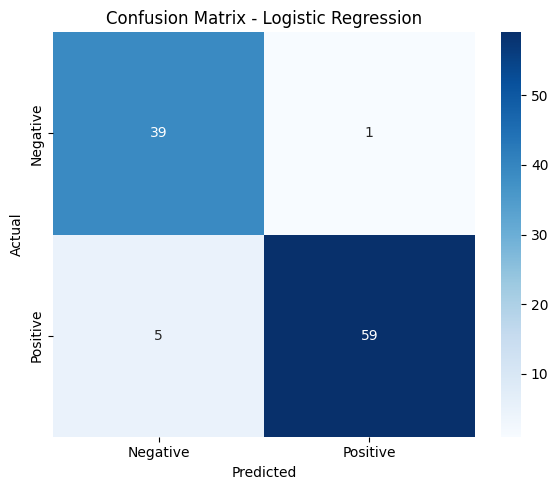

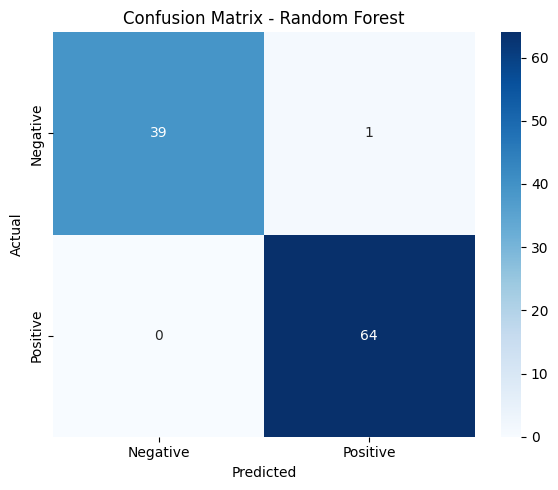

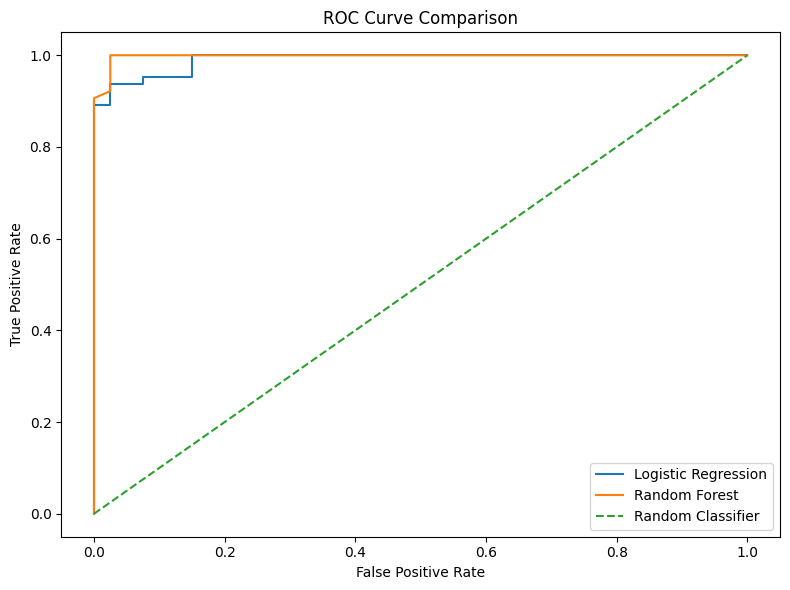


Top 15 important features:
                                Feature  Importance
6            categorical__polydipsia_No    0.117975
5             categorical__polyuria_Yes    0.107040
4              categorical__polyuria_No    0.097768
7           categorical__polydipsia_Yes    0.095837
3              categorical__gender_Male    0.063675
0                          numeric__age    0.057551
1                numeric__symptom_count    0.056472
2            categorical__gender_Female    0.048906
8    categorical__sudden_weight_loss_No    0.027846
25     categorical__partial_paresis_Yes    0.023590
24      categorical__partial_paresis_No    0.022920
9   categorical__sudden_weight_loss_Yes    0.022347
28             categorical__alopecia_No    0.022132
29            categorical__alopecia_Yes    0.020941
21        categorical__irritability_Yes    0.017263


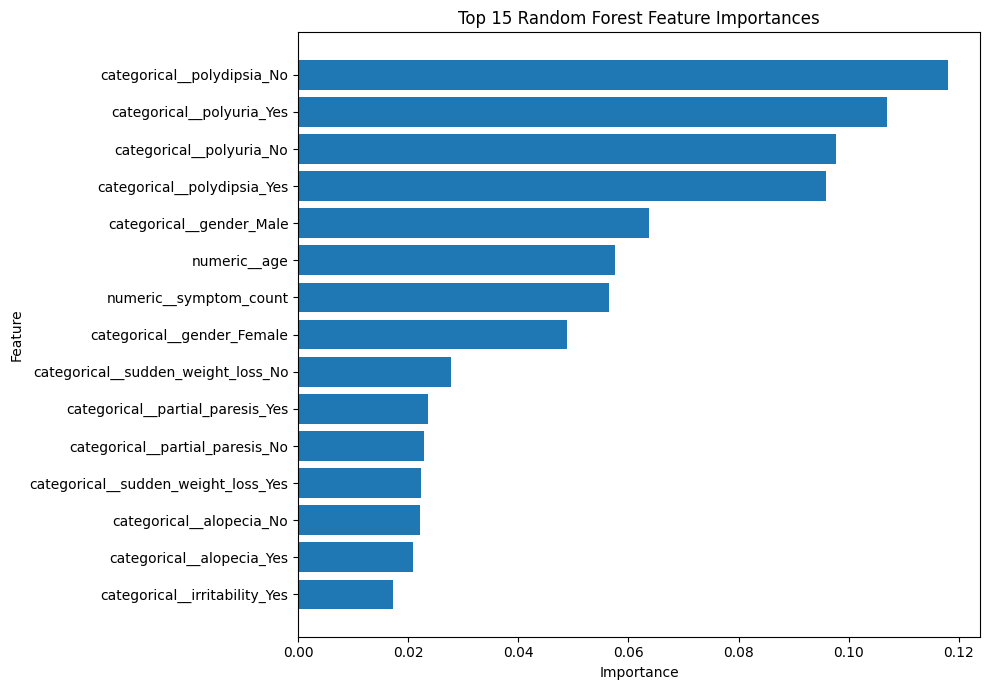


SOFTWARE INFORMATION
Python version:
3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]

Pandas version:
2.2.3

NumPy version:
2.1.3

Scikit-learn version:
1.6.1

Random seed:
42

Random Forest model saved to:
outputs/models/random_forest_diabetes_model.pkl

SOFTWARE INFORMATION
Python version:
3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]

Pandas version:
2.2.3

NumPy version:
2.1.3

Scikit-learn version:
1.6.1

Random seed:
42

Random Forest model saved to:
outputs/models/random_forest_diabetes_model.pkl


/tmp/ipykernel_903/347386040.py:210: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  symptom_data = (df[available_columns].replace(binary_values))



NEW PATIENT SCREENING RESULT
Prediction: Positive
Probability of Positive classification: 99.00%

        DIABETES SCREENING SYSTEM


In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import os
from datetime import datetime

# PROJECT INFORMATION

PROJECT_NAME = "AI Based Clinical Laboratory Screening System"
DATASET_ID = 529
RANDOM_STATE = 42

# CREATING PROJECT FOLDERS

folders = [
    "data/raw",
    "data/processed",
    "outputs/figures",
    "outputs/tables",
    "outputs/models",
    "../PythonProject/data/raw",
    "../PythonProject/data/processed",
    "../PythonProject/outputs/figures",
    "../PythonProject/outputs/tables",
    "../PythonProject/outputs/models"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# TASK 1: COLLECTING DATA FROM UCI

print("_" * 50)
print("Step 4: DATA ACQUISITION")
print("_" * 50)

print("Connecting to UCI ML Repository...")

dataset = fetch_ucirepo(id=DATASET_ID)

X = dataset.data.features
y = dataset.data.targets

print("\nDataset successfully retrieved.")

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nNumber of feature records:", len(X))
print("Number of features:", X.shape[1])

# COMBINING FEATURES AND TARGET

data = X.copy()

target_column = y.columns[0]
data[target_column] = y[target_column]


# SAVE RAW DATA

raw_file = "../PythonProject/data/raw/diabetes_raw.csv"

data.to_csv(raw_file, index=False)

print("\nRaw dataset saved to:")
print(raw_file)


# COLLECTION LOG

collection_log = {
    "project": PROJECT_NAME,
    "dataset": "Early Stage Diabetes Risk Prediction",
    "source": "UCI Machine Learning Repository",
    "UCI_dataset_id": DATASET_ID,
    "collection_method": "Programmatic retrieval using ucimlrepo",
    "collection_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "number_of_records": len(data),
    "number_of_columns": len(data.columns),
    "raw_file": raw_file
}

log_df = pd.DataFrame([collection_log])

log_df.to_csv(
    "data/raw/data_collection_log.csv",
    index=False
)

print("\nCollection log saved.")

print("\nTask 1 completed.")

# TASK 2: DATA PROFILING

print("\n" + "_" * 60)
print("TASK 2: DATA PROFILING")
print("_" * 60)

print("\nFirst five records:")
print(data.head())

print("\nDataset shape:")
print(data.shape)

print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate records:")
print(data.duplicated().sum())

print("\nUnique values:")
for column in data.columns:
    print(
        f"{column}: "
        f"{data[column].nunique(dropna=True)} unique values"
    )

print("\nDescriptive statistics:")
print(data.describe(include="all"))

print("\nTarget distribution:")
print(data[target_column].value_counts())
#%%
#CUSTOM DATA PREPROCESSOR

class MedicalDataPreprocessor:

    def __init__(self):
        self.removed_duplicates = 0

    def clean_column_names(self, df):
        """Standardise column names."""

        df = df.copy()
        df.columns = (df.columns.str.strip().str.lower().str.replace(" _", "_").str.replace("-", "_"))

        return df

    def clean_values(self, df):
        """Clean text values and convert unknown values to NaN."""

        df = df.copy()

        for column in df.columns:

            if df[column].dtype == "object":

                df[column] = (df[column].astype(str).str.strip())

                df[column] = df[column].replace(["?", "NA", "N/A", "null", "None", ""],np.nan)

        return df

    def convert_age(self, df):
        """Convert age to numeric."""

        df = df.copy()

        if "age" in df.columns:
            df["age"] = pd.to_numeric(
                df["age"],errors="coerce")
        return df
    def remove_duplicates(self, df):
        """Remove duplicate observations."""

        df = df.copy()
        before = len(df)
        df = df.drop_duplicates()
        after = len(df)

        self.removed_duplicates = before - after
        return df
    def create_features(self, df):
        """Create useful derived features."""

        global binary_values
        df = df.copy()
        symptom_columns = [
            "polyuria",
            "polydipsia",
            "sudden_weight_loss",
            "weakness",
            "polyphagia",
            "genital_thrush",
            "visual_blurring",
            "itching",
            "irritability",
            "delayed_healing",
            "partial_paresis",
            "muscle_stiffness",
            "alopecia",
            "obesity"]

        available_columns = [col for col in symptom_columns if col in df.columns]

        if available_columns: binary_values = {"Yes": 1,"No": 0 }

        symptom_data = (df[available_columns].replace(binary_values))

        symptom_data = symptom_data.apply(pd.to_numeric,errors="coerce")

        df["symptom_count"] = symptom_data.sum(axis=1,skipna=True )

        return df

    def process(self, df):
        """Run the complete cleaning process."""

        df = self.clean_column_names(df)
        df = self.clean_values(df)
        df = self.convert_age(df)
        #df = self.removed_duplicates(df)
        df = self.create_features(df)

        return df
#%%
# APPLY CUSTOM PREPROCESSING

print("\nApplying custom preprocessing...")

preprocessor = MedicalDataPreprocessor()

clean_data = preprocessor.process(data)

print("\nNumber of duplicate records removed:")
#print(preprocessor.removed_duplicates)

print("\nCleaned column names:")
print(clean_data.columns.tolist())

print("\nCleaned data preview:")
print(clean_data.head())
#%%
print("\n" + "_" * 50)
print("BEFORE VS AFTER PREPROCESSING")
print("_" * 50)

print("\nBEFORE:")
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])
print("Duplicates:", data.duplicated().sum())
print("Missing values:", data.isnull().sum().sum())

print("\nAFTER:")
#print("Rows:", clean_data.shape[0])
print("Columns:", clean_data.shape[1])
print("Duplicates:", clean_data.duplicated().sum())
print("Missing values:", clean_data.isnull().sum().sum())
#%%
processed_file = "../PythonProject/data/processed/diabetes_prepared.csv"

#preprocessor = MedicalDataPreprocessor()
#clean_data = preprocessor.process(data)

clean_data.to_csv(processed_file,index=False)

print("\nPrepared dataset saved to:")
print(processed_file)
#%%

#%%
# TASK 3: PREPARE FEATURES AND TARGET

print("\n" + "_" * 50)
print("TASK 3: MACHINE LEARNING")
print("_" * 50)

target_column = "class"

X = clean_data.drop(columns=[target_column])
y = clean_data[target_column]

print("\nTarget column:")
print(target_column)

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())
#%%

# ENCODE TARGET(Convert the target)

target_mapping = {
    "Positive": 1,
    "Negative": 0,
    "positive": 1,
    "negative": 0
}

y = y.replace(target_mapping)

y = pd.to_numeric(y, errors="coerce")

valid_rows = y.notna()

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].astype(int)

print("\nEncoded target distribution:")
print(y.value_counts())
#%%
# IDENTIFY FEATURE TYPES(Identify numerical and categorical variables)

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)
#%%
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# PREPROCESSING PIPELINE

numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())
    ])

categorical_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

preprocessing = ColumnTransformer(transformers=[("numeric",numeric_pipeline,numeric_features),("categorical", categorical_pipeline,categorical_features)
    ])
#%%
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# BASELINE MODEL(logistic regression)

logistic_model = Pipeline(
    steps=[
        ("preprocessing",preprocessing),("model",LogisticRegression(max_iter=1000,random_state=RANDOM_STATE))])

print("\nTraining Logistic Regression...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Logistic Regression training completed.")
#%%
from sklearn.ensemble import RandomForestClassifier
# PROPOSED MODEL (Random forest)

random_forest_model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),("model",RandomForestClassifier(n_estimators=200,max_depth=None,min_samples_split=2,
                random_state=RANDOM_STATE,class_weight="balanced"))])

print("\nTraining Random Forest...")

random_forest_model.fit(X_train,y_train)

print("Random Forest training completed.")
#screening.py regression
# PREDICTIONS

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

random_forest_predictions = random_forest_model.predict(X_test)

logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)

# EVALUATION FUNCTION

def evaluate_model(model_name,y_true,predictions,probabilities):
    """Calculate classification performance metrics."""

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score( y_true,predictions),
        "Precision": precision_score(y_true,predictions,zero_division=0),
        "Recall": recall_score(y_true,predictions,zero_division=0),
        "F1": f1_score(y_true,predictions,zero_division=0),
        "ROC_AUC": roc_auc_score(y_true,probabilities)
    }

    return results

# MODEL COMPARISON

logistic_results = evaluate_model(
   "Logistic Regression",y_test,logistic_predictions,logistic_probabilities)

random_forest_results = evaluate_model("Random Forest",y_test,random_forest_predictions,random_forest_probabilities)

results = pd.DataFrame([logistic_results,random_forest_results])

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(results)


results.to_csv(
    "outputs/tables/model_comparison.csv",
    index=False
)
#%%
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# CONFUSION MATRIX FUNCTION

def plot_confusion_matrix(
    y_true,
    predictions,
    model_name,
    filename
):
    """Plot and save a confusion matrix."""

    cm = confusion_matrix(y_true,predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues", xticklabels=["Negative","Positive"],
        yticklabels=["Negative","Positive"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")

    plt.tight_layout()

    plt.savefig(filename,dpi=300)

    plt.show()
#ploting part, logistic regression
plot_confusion_matrix(y_test, logistic_predictions,"Logistic Regression",
                      "../PythonProject/outputs/figures/logistic_confusion_matrix.png")

plot_confusion_matrix(y_test, random_forest_predictions,"Random Forest",
                      "../PythonProject/outputs/figures/random_forest_confusion_matrix.png")
#%%
from sklearn.metrics import roc_curve
# ROC CURVE


def plot_roc_curve(y_true,logistic_probabilities, random_forest_probabilities):

    logistic_fpr, logistic_tpr, _ = roc_curve(y_true,logistic_probabilities)

    rf_fpr, rf_tpr, _ = roc_curve(y_true,random_forest_probabilities)

    plt.figure(figsize=(8, 6))

    plt.plot(logistic_fpr,logistic_tpr,label="Logistic Regression" )

    plt.plot(rf_fpr,rf_tpr,label="Random Forest")

    plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve Comparison")

    plt.legend()

    plt.tight_layout()

    plt.savefig("outputs/figures/roc_curve_comparison.png",dpi=300)

    plt.show()


plot_roc_curve(y_test,logistic_probabilities, random_forest_probabilities)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# RANDOM FOREST FEATURE IMPORTANCE

rf_preprocessor = (random_forest_model.named_steps["preprocessing"])

rf_model = (random_forest_model.named_steps["model"])

feature_names = (rf_preprocessor.get_feature_names_out())

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({"Feature": feature_names,"Importance": importance})

feature_importance = (feature_importance.sort_values(by="Importance",ascending=False))

print("\nTop 15 important features:")

print(feature_importance.head(15))


feature_importance.to_csv("outputs/tables/feature_importance.csv",index=False)
#%%%%%%%%%%%%%%%%%
# FEATURE IMPORTANCE PLOT

top_features = (feature_importance.head(15).sort_values(by="Importance"))

plt.figure(figsize=(10, 7))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()

plt.savefig("outputs/figures/feature_importance.png", dpi=300)

plt.show()
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
import sys
import sklearn

# SOFTWARE INFORMATION

print("\n" + "=" * 60)
print("SOFTWARE INFORMATION")
print("=" * 60)

print("Python version:")
print(sys.version)

print("\nPandas version:")
print(pd.__version__)

print("\nNumPy version:")
print(np.__version__)

print("\nScikit-learn version:")
print(sklearn.__version__)

print("\nRandom seed:")
print(RANDOM_STATE)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
import joblib

# SAVE MODEL

model_file = "outputs/models/" "random_forest_diabetes_model.pkl"

joblib.dump(random_forest_model,model_file)

print("\nRandom Forest model saved to:")
print(model_file)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
import sys
import sklearn
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# SOFTWARE INFORMATION

print("\n" + "=" * 60)
print("SOFTWARE INFORMATION")
print("=" * 60)

print("Python version:")
print(sys.version)

print("\nPandas version:")
print(pd.__version__)

print("\nNumPy version:")
print(np.__version__)

print("\nScikit-learn version:")
print(sklearn.__version__)

print("\nRandom seed:")
print(RANDOM_STATE)
#%%
import joblib

# SAVE MODEL

model_file = "outputs/models/" "random_forest_diabetes_model.pkl"

joblib.dump(random_forest_model,model_file)

print("\nRandom Forest model saved to:")
print(model_file)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# NEW PATIENT ENTRY

joblib.dump(random_forest_model, model_file)

# NEW PATIENT SCREENING

def predict_new_patient(model,patient_data):
    """
    Predict diabetes classification for a new patient.
    """

    #We convert patient information into a DataFrame
    new_patient = pd.DataFrame([patient_data])

    # Apply the same cleaning and feature engineering
    # used during model development
    new_patient = preprocessor.process(new_patient)

    # Make prediction
    prediction = model.predict(new_patient)[0]

    # Get probability
    probability = model.predict_proba(new_patient)[0][1]

    # we convert numerical prediction back to label
    if prediction == 1:
        result = "Positive"
    else:
        result = "Negative"

    print("\n" + "=" * 50)
    print("NEW PATIENT SCREENING RESULT")
    print("=" * 50)

    print("Prediction:", result)
    print(f"Probability of Positive classification: {probability * 100:.2f}%")

    return result, probability

# TEST PATIENT

new_patient = {
    "age": 24,
    "gender": "Female",
    "polyuria": "Yes",
    "polydipsia": "Yes",
    "sudden_weight_loss": "yes",
    "weakness": "Yes",
    "polyphagia": "Yes",
    "genital_thrush": "No",
    "visual_blurring": "Yes",
    "itching": "yes",
    "irritability": "No",
    "delayed_healing": "Yes",
    "partial_paresis": "yes",
    "muscle_stiffness": "yes",
    "alopecia": "No",
    "obesity": "Yes"
}
result, probability = predict_new_patient(random_forest_model,new_patient)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# INTERACTIVE NEW PATIENT SCREENING

def get_yes_no(question):
    """Ask the user a Yes/No question."""

    while True:
        answer = input(f"{question} (Yes/No): ").strip().lower()
        if answer in ["yes", "y"]:
            return "Yes"
        elif answer in ["no", "n"]:
            return "No"
        else:
            print("Please enter Yes or No.")

def get_gender():
    """Ask the user to enter the patient's gender."""
    while True:
        gender = input("Enter patient's gender (Male/Female): ").strip().lower()
        if gender == "male":
            return "Male"
        elif gender == "female":
            return "Female"
        else:
            print("Please enter Male or Female.")

def get_age():
    """Ask the user to enter a valid age."""
    while True:
        try:
            age = int(input("Enter patient's age: "))
            if 1 <= age <= 120:
                return age
            print("Please enter an age between 1 and 120.")
        except ValueError:
            print("Please enter a valid number.")
def screen_new_patient(model):
    """
    Collect information about a new patient
    and use the trained model to make a prediction.
    """
    print("\n" + "=" * 60)
    print("        DIABETES SCREENING SYSTEM")
    print("=" * 60)

    # Patient information
    age = get_age()
    gender = get_gender()

    # Symptoms
    polyuria = get_yes_no("Does the patient have polyuria?")
    polydipsia = get_yes_no("Does the patient have polydipsia?")
    sudden_weight_loss = get_yes_no("Has the patient experienced sudden weight loss?")
    weakness = get_yes_no("Does the patient experience weakness?")
    polyphagia = get_yes_no("Does the patient experience polyphagia?")
    genital_thrush = get_yes_no("Does the patient have genital thrush?")
    visual_blurring = get_yes_no("Does the patient experience visual blurring?")
    itching = get_yes_no("Does the patient experience itching?")
    irritability = get_yes_no("Does the patient experience irritability?")
    delayed_healing = get_yes_no("Does the patient have delayed healing?")
    partial_paresis = get_yes_no("Does the patient have partial paresis?")
    muscle_stiffness = get_yes_no("Does the patient have muscle stiffness?")
    alopecia = get_yes_no("Does the patient have alopecia?")
    obesity = get_yes_no("Does the patient have obesity?")

    # we Put the answers into a DataFrame
    patient = pd.DataFrame([{
        "age": age,
        "gender": gender,
        "polyuria": polyuria,
        "polydipsia": polydipsia,
        "sudden_weight_loss": sudden_weight_loss,
        "weakness": weakness,
        "polyphagia": polyphagia,
        "genital_thrush": genital_thrush,
        "visual_blurring": visual_blurring,
        "itching": itching,
        "irritability": irritability,
        "delayed_healing": delayed_healing,
        "partial_paresis": partial_paresis,
        "muscle_stiffness": muscle_stiffness,
        "alopecia": alopecia,
        "obesity": obesity
    }])

    #we are Using the same custom preprocessing used during development
    patient = preprocessor.process(patient)

    # Make prediction
    prediction = model.predict(patient)[0]

    # Get probability
    probability = model.predict_proba(patient)[0][1]

    # Convert prediction to readable result
    if prediction == 1:
        result = "Positive"
    else:
        result = "Negative"

    # Display result
    print("\n" + "=" * 60)
    print("             SCREENING RESULT")
    print("=" * 60)

    print(f"Classification: {result}")
    print(f"Predicted probability of Positive: {probability * 100:.2f}%")

    print("\nImportant:")
    #print("This is a machine-learning screening result.")
    #print("It is NOT a medical diagnosis.")
    #print("Further clinical assessment should be performed by")
    #print("a qualified healthcare professional.")

    print("=" * 60)

    return patient, result, probability

screen_new_patient(random_forest_model)

#creating window
import tkinter as tk
from tkinter import ttk

# MAIN WINDOW

root = tk.Tk()
root.title("Diabetes Screening System")
root.geometry("700x700")
root.resizable(False, False)


# TITLE

title = tk.Label(root,text="DIABETES SCREENING SYSTEM",font=("Arial", 20, "bold"))

title.pack(pady=20)

subtitle = tk.Label(root,text="AI-Based Clinical Laboratory Screening and Decision Support",font=("Arial", 10))

subtitle.pack(pady=(0, 20))

# PATIENT INFORMATION

patient_frame = ttk.LabelFrame(root,text="Patient Information",padding=15)

patient_frame.pack(padx=30,  pady=10,fill="x")

# Age
ttk.Label(patient_frame,text="Patient Age:").grid(row=0, column=0, padx=10, pady=10, sticky="w")

age_entry = ttk.Entry(patient_frame, width=30)

age_entry.grid(row=0, column=1, padx=10, pady=10)

# Gender
ttk.Label(patient_frame, text="Gender:").grid(row=1, column=0, padx=10, pady=10,sticky="w")

gender = ttk.Combobox(patient_frame,values=["Male", "Female"], state="readonly", width=27)

gender.grid(row=1,column=1, padx=10, pady=10)

# SYMPTOMS PART

symptoms_frame = ttk.LabelFrame(root, text="Patient Symptoms", padding = 15)

symptoms_frame.pack(padx=30, pady=10, fill="both")

# Symptoms
symptoms = [
    "Polyuria",
    "Polydipsia",
    "Sudden Weight Loss",
    "Weakness",
    "Polyphagia",
    "Genital Thrush",
    "Visual Blurring",
    "Itching",
    "Irritability",
    "Delayed Healing",
    "Partial Paresis",
    "Muscle Stiffness",
    "Alopecia",
    "Obesity"
]
# Store dropdown wdges
symptom_inputs = {}

for index, symptom in enumerate(symptoms):

    row = index % 7
    column = (index // 7) * 2

    ttk.Label(symptoms_frame, text=symptom + ":").grid(row=row, column=column, padx=10, pady=7, sticky="w")

    combo = ttk.Combobox(symptoms_frame,values=["Yes", "No"], state="readonly", width=10)

    combo.grid(row=row, column=column + 1, padx=10, pady=7)

    symptom_inputs[symptom] = combo

# BUTTONS

button_frame = ttk.Frame(root)

button_frame.pack(pady=20)

screen_button = ttk.Button(button_frame, text="SCREEN PATIENT")

screen_button.grid(row=0, column=0, padx=10)

clear_button = ttk.Button( button_frame,text="CLEAR")

clear_button.grid(row=0,column=1,padx=10)

# RESULT FRAME

result_frame = ttk.LabelFrame(root,text="Screening Result",padding=15)

result_frame.pack(padx=30,pady=10,fill="x")

result_label = ttk.Label(result_frame,text="No screening performed yet.",font=("Arial", 12))

result_label.pack(pady=10)

# DISCLAIMER

disclaimer = ttk.Label(root,text=(
        "This system is a machine-learning screening tool "
        "and is NOT a medical diagnosis."),font=("Arial", 9))

disclaimer.pack(pady=10)

# START APPLICATION
root.mainloop()